<a href="https://colab.research.google.com/github/GlushkoIlya/TPNS2/blob/main/lab1/lab1_lib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для визуализации и предобработки
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import mutual_info_regression

# Для Gain Ratio (используем энтропию через DecisionTree)
from sklearn.metrics import mutual_info_score
import math

# Для игнорирования предупреждений
import warnings
warnings.filterwarnings('ignore')

# Для отображения графиков в Colab
%matplotlib inline

In [6]:
# Загрузка данных
df = pd.read_csv('/Laptop_price.csv')

# Первые 5 строк
print("Первые 5 строк датасета:")
display(df.head())

# Общая информация о датасете
print("\nИнформация о датасете:")
df.info()

# Описательная статистика для числовых признаков
print("\nОписательная статистика:")
display(df.describe())

# Проверка на пропуски
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())

Первые 5 строк датасета:


,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB

Описательная статистика:


,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037



Количество пропусков в каждом столбце:
Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Кодируем бренд числовыми метками (Label Encoding)
le = LabelEncoder()
df['Brand_encoded'] = le.fit_transform(df['Brand'])
print("Соответствие брендов и кодов:")
for brand, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"{brand}: {code}")

Соответствие брендов и кодов:
Acer: 0
Asus: 1
Dell: 2
HP: 3
Lenovo: 4


In [ ]:
# Выделим числовые признаки (все, кроме Brand и Price)
numeric_cols = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                'Screen_Size', 'Weight', 'Brand_encoded']

# Для тепловой карты нам нужно масштабирование, но для Gain Ratio оно не требуется
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

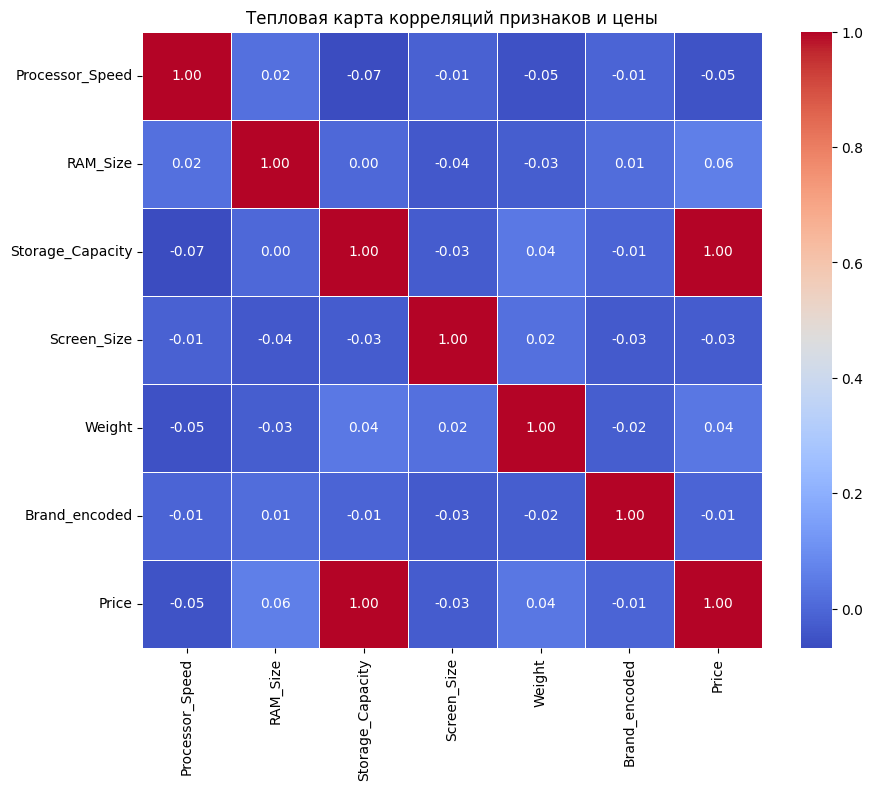

In [ ]:
# Построим тепловую матрицу корреляций (используем масштабированные данные + цену)
corr_matrix = df_scaled[numeric_cols + ['Price']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляций признаков и цены')
plt.show()

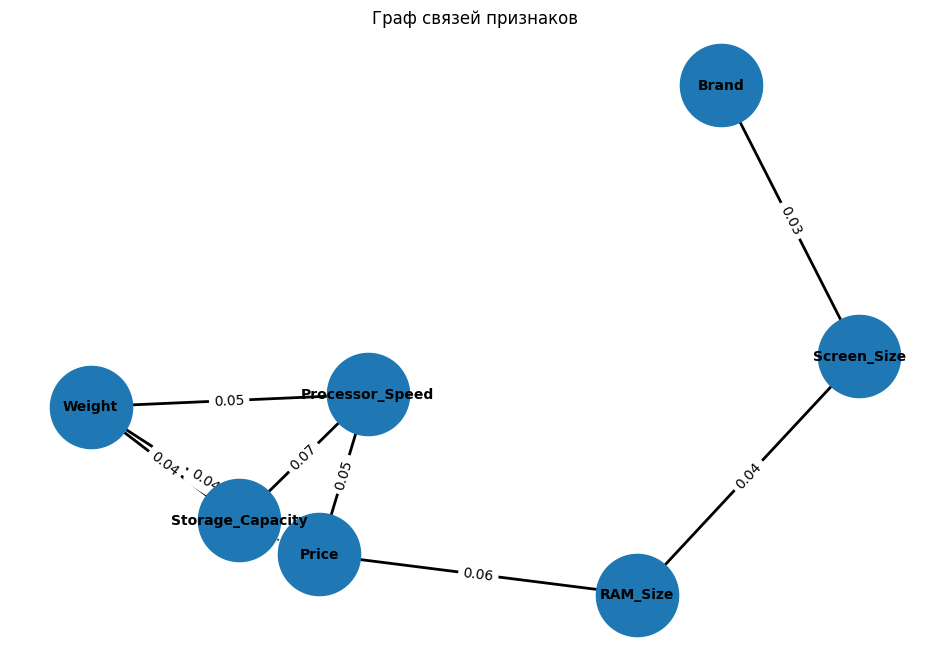

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Кодирование категориального признака
# ---------------------------------------------------------

encoder = LabelEncoder()

df['Brand'] = encoder.fit_transform(df['Brand'])

# ---------------------------------------------------------
# Корреляционная матрица
# ---------------------------------------------------------

corr_matrix = df.corr(numeric_only=True)

# ---------------------------------------------------------
# Создание графа
# ---------------------------------------------------------

G = nx.Graph()

# Добавление узлов

for column in corr_matrix.columns:
    G.add_node(column)

# ---------------------------------------------------------
# Добавление связей
# ---------------------------------------------------------

threshold = 0.03

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:

            G.add_edge(
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                weight=round(abs(corr_value), 2)
            )

# ---------------------------------------------------------
# Визуализация
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title('Граф связей признаков')

plt.axis('off')

plt.show()


Feature Importance (DecisionTree max_depth=3):

            Feature  Feature_Importance
3  Storage_Capacity            0.996883
2          RAM_Size            0.003093
1   Processor_Speed            0.000024
0             Brand            0.000000
4       Screen_Size            0.000000
5            Weight            0.000000


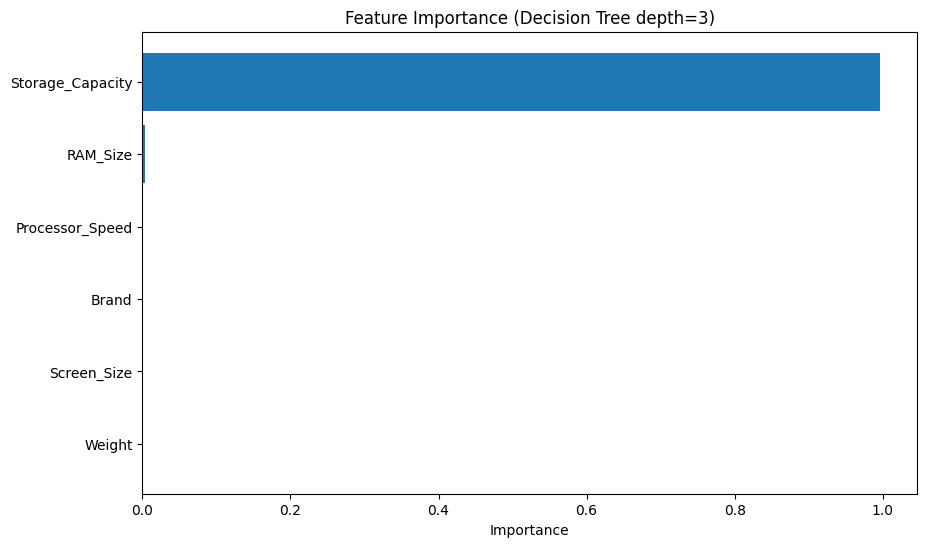

In [8]:
# =========================================================
# ДОПОЛНИТЕЛЬНЫЙ БЛОК: Decision Tree + Feature Importance
# =========================================================

from sklearn.tree import DecisionTreeRegressor

X = df.drop('Price', axis=1)
y = df['Price']

X = X.copy()
if X['Brand'].dtype == 'object':
    le = LabelEncoder()
    X['Brand'] = le.fit_transform(X['Brand'])

# Обучаем самый простой decision tree
tree_simple = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_simple.fit(X, y)

# Получаем feature importance
feature_importance = tree_simple.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Feature_Importance': feature_importance
})

# Сортировка по убыванию важности
importance_df = importance_df.sort_values(
    by='Feature_Importance',
    ascending=False
)

print("\nFeature Importance (DecisionTree max_depth=3):\n")
print(importance_df)

# Визуализация
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Feature_Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (Decision Tree depth=3)')
plt.xlabel('Importance')
plt.show()

In [ ]:
# Реализация Gain Ratio (исправленная версия)

def entropy(y):
    """Вычисление энтропии Шеннона"""
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

def gain_ratio(X, y):
    """
    Вычисление Gain Ratio для заданного признака (числового или категориального)
    X - признак (вектор)
    y - целевая переменная (непрерывная)
    """
    # Дискретизируем признак для дерева (используем квантили)
    unique_vals = np.unique(X)
    if len(unique_vals) > 10:
        # Для непрерывных признаков разбиваем на 5 корзин (квантили)
        bins = np.percentile(X, np.linspace(0, 100, 6))[1:-1]
        X_discrete = np.digitize(X, bins)
    else:
        X_discrete = X

    # Энтропия всей выборки (нужно дискретизировать цену для энтропии)
    y_discrete = pd.cut(y, bins=5, labels=False)
    total_entropy = entropy(y_discrete)

    # Information Gain
    weighted_entropy = 0
    split_info = 0
    total_n = len(y)

    for val in np.unique(X_discrete):
        mask = (X_discrete == val)
        n_val = mask.sum()
        if n_val == 0:
            continue
        weight = n_val / total_n
        y_sub = y_discrete[mask]
        weighted_entropy += weight * entropy(y_sub)
        # Split Information = -sum(p_i * log2(p_i))
        p_i = n_val / total_n
        split_info -= p_i * np.log2(p_i + 1e-9)

    info_gain = total_entropy - weighted_entropy
    if split_info == 0:
        return 0
    return info_gain / split_info

# Вычисляем Gain Ratio для каждого признака
X = df_scaled[numeric_cols].values
y = df_scaled['Price'].values

gain_ratios = {}
for i, col in enumerate(numeric_cols):
    gr = gain_ratio(X[:, i], y)  # Убрали лишний аргумент feature_idx
    gain_ratios[col] = gr

# Сортируем по убыванию
sorted_gain_ratio = sorted(gain_ratios.items(), key=lambda x: x[1], reverse=True)
print("Gain Ratio для признаков (чем выше, тем важнее):")
for feature, gr in sorted_gain_ratio:
    print(f"{feature}: {gr:.4f}")

Gain Ratio для признаков (чем выше, тем важнее):
Storage_Capacity: 1.0000
RAM_Size: 0.0132
Processor_Speed: 0.0070
Brand_encoded: 0.0048
Screen_Size: 0.0047
Weight: 0.0032


In [ ]:
# Выберем признаки с Gain Ratio > 0.2 (порог можно менять)
important_features = [f for f, gr in sorted_gain_ratio if gr > 0.2]
print("\nНаиболее важные признаки для модели:")
print(important_features)

# Создаем новый датасет только с важными признаками + ценой
df_selected = df[important_features + ['Price']].copy()
print("\nРазмерность нового датасета:", df_selected.shape)
display(df_selected.head())


Наиболее важные признаки для модели:
['Storage_Capacity']

Размерность нового датасета: (1000, 2)


,Storage_Capacity,Price
0,512,17395.093065
1,1000,31607.605919
2,256,9291.023542
3,512,17436.728334
4,1000,32917.990718


In [ ]:
# Подготовка данных
X_selected = df_selected.drop('Price', axis=1)
y = df_selected['Price']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Обучение дерева решений
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Прогнозы
y_pred = model.predict(X_test)

# Вывод нескольких прогнозов
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Первые 10 прогнозов:")
display(results.head(10))

Первые 10 прогнозов:


,Actual,Predicted
521,10900.502075,9741.467920
737,31727.516697,32026.760160
740,9636.022750,9741.467920
660,9412.599857,9741.467920
411,31641.105861,32026.760160
678,31832.486943,32026.760160
626,10438.451568,9741.467920
513,17205.205679,17441.452006
859,18743.569392,17441.452006
136,32342.705862,32026.760160


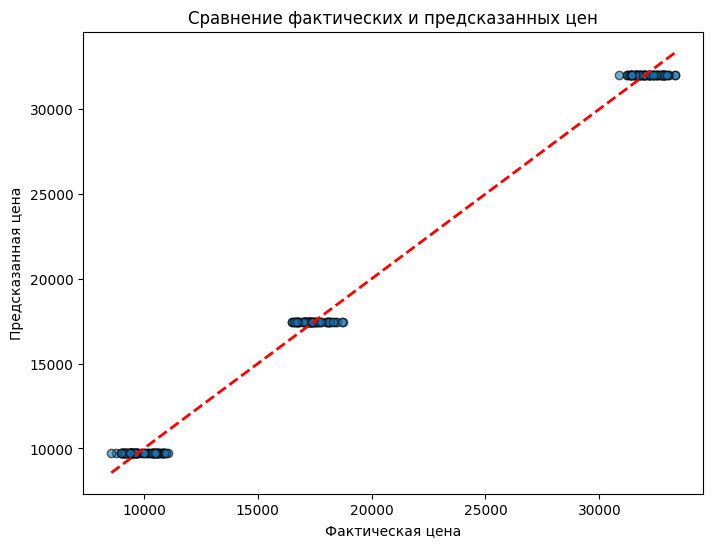

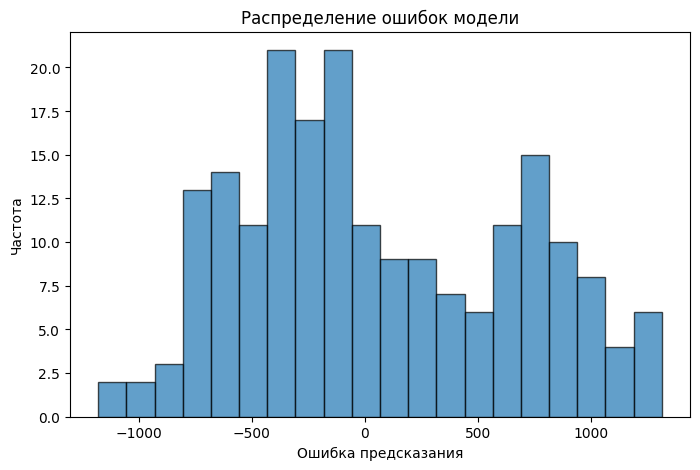


Таблица важности признаков:
            Признак  Важность
0  Storage_Capacity       1.0


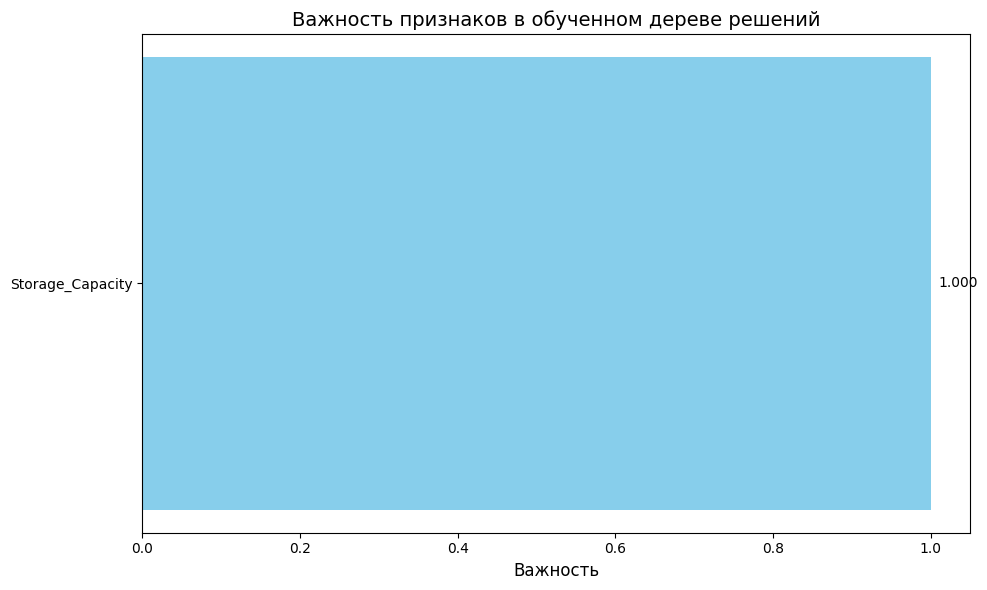

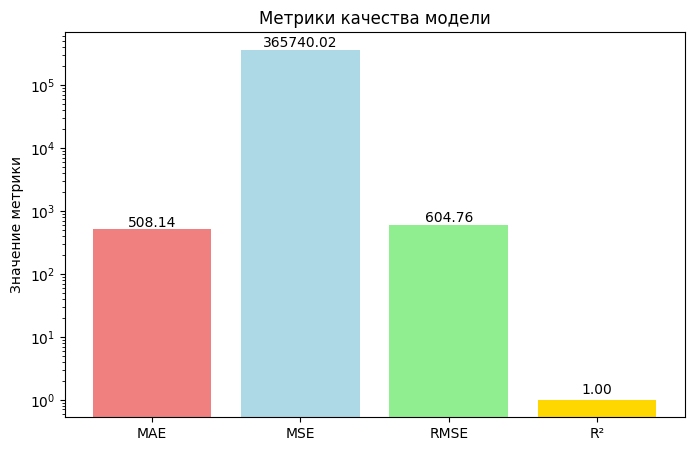


Метрики качества модели:
MAE (Средняя абсолютная ошибка): 508.14
MSE (Среднеквадратичная ошибка): 365740.02
RMSE (Корень из MSE): 604.76
R² (Коэффициент детерминации): 0.9960


In [ ]:
# Блок 8: Графики выходных результатов (ИСПРАВЛЕННАЯ ВЕРСИЯ)

# 1. График: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение фактических и предсказанных цен')
plt.show()

# 2. Гистограмма ошибок
errors = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title('Распределение ошибок модели')
plt.show()

# 3. Важность признаков (ИСПРАВЛЕННАЯ ВЕРСИЯ)
feature_importance = model.feature_importances_

# Создаем DataFrame для удобного отображения
importance_df = pd.DataFrame({
    'Признак': X_selected.columns,
    'Важность': feature_importance
}).sort_values('Важность', ascending=False)

print("\nТаблица важности признаков:")
print(importance_df)

# График важности признаков (горизонтальная столбчатая диаграмма)
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'], color='skyblue')
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков в обученном дереве решений', fontsize=14)
plt.gca().invert_yaxis()

# Добавляем значения на столбцы
for i, (bar, val) in enumerate(zip(bars, importance_df['Важность'])):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Дополнительный график: метрики качества модели
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Визуализация метрик
metrics = ['MAE', 'MSE', 'RMSE', 'R²']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.ylabel('Значение метрики')
plt.title('Метрики качества модели')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации

# Добавляем значения на столбцы
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()

print("\nМетрики качества модели:")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f}")
print(f"MSE (Среднеквадратичная ошибка): {mse:.2f}")
print(f"RMSE (Корень из MSE): {rmse:.2f}")
print(f"R² (Коэффициент детерминации): {r2:.4f}")